## Notebook 4: Results Comparison

This notebook is the final step in our pipeline. The goal is to bring the results obtained from PCA and Differential Expression Analysis notebooks and compare them using Venn diagrams. By finding the overlap between these two methods, we can can check how many genes were commonly identified by the two methods.

---
### Data Source:

This notebook does not use the raw dataset directly. Instead, it uses the extracted gene lists generated in Notebook 3 (PCA) and Notebook 2 (Differential Expression Analysis).

* **PCA Gene List**: `top_pc_contributing_genes.csv`
* **DEA Gene List**: `top_100_dea_genes.csv`

---

In [1]:
# Install matplotlib-venn in your system if it does not exist by default:
# !pip install matplotlib-venn

In [1]:
# importing libraries for data handling and visualisation
import pandas as pd
from matplotlib_venn import venn2, venn2_circles
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [13]:
# Load the two gene lists into pandas DataFrames

# Load the list of top genes from PCA
pc1_genes_df = pd.read_csv("top_pc1_contributing_genes.csv")
pc2_genes_df = pd.read_csv("top_pc2_contributing_genes.csv")
pc3_genes_df = pd.read_csv("top_pc3_contributing_genes.csv")
pc4_genes_df = pd.read_csv("top_pc4_contributing_genes.csv")

# Load the list of significant genes from DEA
dea_genes_df = pd.read_csv("dea_top_100_gene_list.csv") 

# Display the first few rows of each DataFrame to confirm they loaded correctly
print("Top Genes from the selected Principal component:")
display(pc4_genes_df)

print("\nTop Genes from Differential Expression Analysis:")
display(dea_genes_df)

Top Genes from the selected Principal component:


,Gene,PC4,abs_PC4
0,CCNA2,0.025429,0.025429
1,KIF2C,0.025338,0.025338
2,CCNB2,0.025306,0.025306
3,AURKB,0.025300,0.025300
4,TPX2,0.025228,0.025228
...,...,...,...
95,CENPI,0.022108,0.022108
96,KIF15,0.022032,0.022032
97,E2F1,0.022031,0.022031
98,CXCL10,0.022030,0.022030



Top Genes from Differential Expression Analysis:


,Gene,log2FoldChange,lfcSE,logCPM,stat,pvalue
0,ANXA9,3.850449,0.003655,4.881777,1600.141121,0.0
1,ABAT,3.413274,0.002729,6.305095,1770.913727,0.0
2,C6orf15,-5.947493,0.018758,2.085959,1882.117988,0.0
3,C5AR2,2.783648,0.002341,4.187570,1519.164331,0.0
4,CDC123,-0.976427,0.000447,5.746475,1700.351825,0.0
...,...,...,...,...,...,...
95,KRT81,-4.871831,0.012435,6.200164,1943.499972,0.0
96,FOXC1,-3.335239,0.002422,4.797960,4557.077097,0.0
97,DLGAP5,-2.319846,0.002972,3.063686,1678.560612,0.0
98,CTSC,-1.624777,0.001552,6.716092,1471.133875,0.0


### Obtaining a list of overlapping genes if found:

- Extract the gene names from each DataFrame into a set
- Make sure to include the right dataframe name to check the results

In [ ]:
# Extract the gene names from each DataFrame into a set

pca_gene_set = set(pc4_genes_df['Gene'])
dea_gene_set = set(dea_genes_df['Gene'])

# Find the intersection of the two sets
overlapping_genes = pca_gene_set.intersection(dea_gene_set)

# Convert the set of overlapping genes to a list for easier viewing
overlapping_genes_list = list(overlapping_genes)

# Print the results
print(f"Number of overlapping genes: {len(overlapping_genes_list)}")

# convert the list into a dataframe so that we can view it as a table:
overlapping_genes_df = pd.DataFrame(overlapping_genes_list, columns=['Overlapping_Biomarker_Candidates'])
display(overlapping_genes_df)

Number of overlapping genes: 15


,Overlapping_Biomarker_Candidates
0,KPNA2
1,DEPDC1
2,EXO1
3,SHCBP1
4,DLGAP5
5,FANCA
6,PLK1
7,RRM2
8,TRIP13
9,PRR11


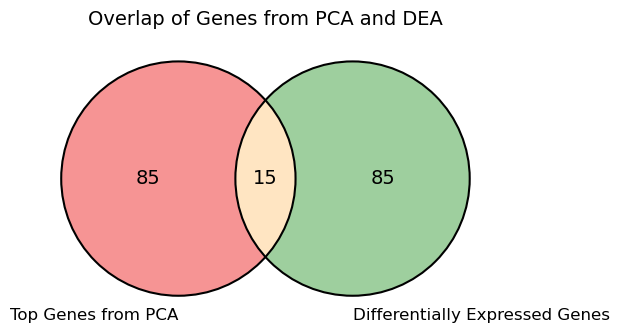

In [15]:
plt.figure(figsize=(6, 6))

# Venn diagram with custom colours to improve overall look
v = venn2(
    subsets=[pca_gene_set, dea_gene_set], 
    set_labels=('Top Genes from PCA', 'Differentially Expressed Genes'),
    set_colors=('#F47A7A', '#86C486'), # choosing custom colours for the circles
    alpha=0.8 # Make the colours slightly transparent
)

# Adding outlines to the circles
c = venn2_circles(
    subsets=[pca_gene_set, dea_gene_set], 
    linestyle='solid', 
    linewidth=1.5, 
    color='black'
)

# Customise the text size of the numbers inside
if v.get_label_by_id('10'): v.get_label_by_id('10').set_fontsize(14) # PCA only
if v.get_label_by_id('01'): v.get_label_by_id('01').set_fontsize(14) # DEA only
if v.get_label_by_id('11'): v.get_label_by_id('11').set_fontsize(14) # Overlap

# Customise the font size of the labels below
if v.get_label_by_id('A'): v.get_label_by_id('A').set_fontsize(12)
if v.get_label_by_id('B'): v.get_label_by_id('B').set_fontsize(12)


plt.title("Overlap of Genes from PCA and DEA", fontsize=14)
plt.show()

### Results:

We compared the top 100 genes from our PCA result (specifically Principal component 4) with the top 100 genes from our Differential Expression Analysis. 

The Venn diagram shows that **15 genes** were commonly identified by both methods.